C:\Users\whdal\AppData\Local\Temp\ipykernel_32596\3016953539.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['IdMax'] = pd.to_numeric(df['IdMax'], errors='coerce')
C:\Users\whdal\AppData\Local\Temp\ipykernel_32596\3016953539.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['block'] = df['IdMax'].notna().cumsum()


                    Vgate Vdrain                    Idrain         IdMax  \
432                    -3    0.1    1.2000000000000002E-13  7.788210e-09   
433                 -2.95    0.1                 -6.79E-13           NaN   
434                  -2.9    0.1                 -6.35E-13           NaN   
435                 -2.85    0.1                  -6.6E-13           NaN   
436   -2.8000000000000003    0.1                 -7.31E-13           NaN   
437                 -2.75    0.1   -6.2400000000000007E-13           NaN   
438                  -2.7    0.1                 -5.86E-13           NaN   
439                 -2.65    0.1                 -6.86E-13           NaN   
440                  -2.6    0.1   -6.9200000000000008E-13           NaN   
441   -2.5500000000000003    0.1                 -6.82E-13           NaN   
442                  -2.5    0.1   -7.1900000000000007E-13           NaN   
443                 -2.45    0.1   -5.7200000000000009E-13           NaN   
444         

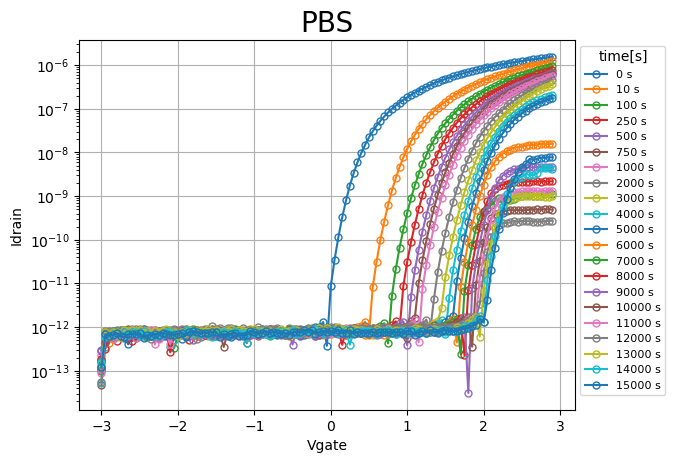

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv


path = "PBTI_IGZO_new2 [260331_WF02_#2_MID_UNITTR_PBS_VG4.5V_15ks_R9(19) ; 4_17_2026 2_23_01 PM].csv"
# csv 鍮덉뭏 ?댁씠 ?쒖옟?좊븣 洹몃?濡??ㅺ퀬?ㅻ뒗 肄붾뱶
rows = []
with open(path, "r", encoding="utf-8-sig", errors="replace", newline="") as f:
    reader = csv.reader(f)
    for r in reader:
        rows.append(r)

max_len = max(len(r) for r in rows)
rows = [r + [""] * (max_len - len(r)) for r in rows]  # 遺議깊븳 ?댁? 鍮덉뭏?쇰줈 梨꾩?

raw_data = pd.DataFrame(rows)  # 紐⑤뱺 ???蹂댁〈??n

# ?먰븯???곗씠?곕쭔 ?ㅺ퀬?ㅺ린
raw_data2 = raw_data[0].isin(['DataValue'])

raw_data = raw_data[raw_data2]
raw_data = raw_data.iloc[:,1:6]
raw_data.columns = ['Vgate','Vdrain','Idrain','IdMax','Vth@Id']


df = raw_data

time = df.loc[df['Idrain'].isin([' ']),'Vgate']
time_list = time.tolist()
time_list = list(reversed(time_list))
time_count = len(time_list)
df = df.iloc[time_count:,:]

df['IdMax'] = pd.to_numeric(df['IdMax'], errors='coerce')

# 1) IdMax媛 議댁옱?섎뒗 ?됰쭏??釉붾줉 踰덊샇 1,2,3,... 利앷?
df['block'] = df['IdMax'].notna().cumsum()

# (?좏깮) 留뚯빟 IdMax ?섏삤湲???援ш컙???덉쑝硫?block=0?몃뜲, 蹂댄넻 ?꾩슂 ?놁쑝???쒓굅
df = df[df['block'] > 0].copy()

# 2) block 踰덊샇瑜?time_list??留ㅽ븨
#    block=1 -> time_list[0], block=2 -> time_list[1], ...
mapping = {i + 1: t for i, t in enumerate(time_list)}

df['time_s'] = df['block'].map(mapping)



# 5) ?뺣━: ?꾩슂 ?녿뒗 block 而щ읆 ?쒓굅?섍퀬 ?뺤씤
print(df[['Vgate','Vdrain','Idrain','IdMax','time_s']].head(30))


df['Vgate']  = pd.to_numeric(df['Vgate'], errors='coerce')
df['Idrain'] = pd.to_numeric(df['Idrain'], errors='coerce').abs()
df['time_s'] = pd.to_numeric(df['time_s'], errors='coerce')

# 2) ?좏슚媛믩쭔 ?④린湲?n
plot_df = df.dropna(subset=['Vgate', 'Idrain', 'time_s']).copy()

# (?좏깮) time ?쒖꽌 ?뺣젹
times = sorted(plot_df['time_s'].unique())

plt.figure()

for t in times:
    d = plot_df[plot_df['time_s'] == t].sort_values('Vgate')
    plt.semilogy(d['Vgate'].to_numpy(), d['Idrain'].to_numpy(),marker = 'o',markerfacecolor = 'none', markersize = 5,linestyle='-', label=f'{int(t)} s')



plt.xlabel('Vgate')
plt.ylabel('Idrain')
plt.title('PBS', fontsize = 20)
plt.legend(title = 'time[s]',bbox_to_anchor=(1, 1), loc='upper left', fontsize = 8)   
plt.grid(True)
plt.show()

In [31]:
W_um = 40
L_um = 20
W_over_L = W_um / L_um

# constant current method? Id/(W/L) ???? ??
target1 = -10  # log10(|Id|/(W/L)) = -10 ??? Vth
target2 = -9   # SS ???: ??? ?? 10? ?? ??

vth_by_time_10 = {}
vth_by_time_9 = {}

for vd, g in df.groupby('time_s'):
    g = g.sort_values('Idrain')

    VG = g['Vgate'].to_numpy()
    ID = g['Idrain'].to_numpy()

    absID = np.abs(ID)
    absID = np.clip(absID, 1e-300, None)
    normID = absID / W_over_L
    logI_norm = np.log10(normID)

    diff1 = logI_norm - target1
    diff2 = logI_norm - target2
    cross_idx_10 = np.where(diff1[:-1] * diff1[1:] <= 0)[0]
    cross_idx_9 = np.where(diff2[:-1] * diff2[1:] <= 0)[0]

    vth_by_time_10[vd] = np.nan
    vth_by_time_9[vd] = np.nan

    if len(cross_idx_10) == 0:
        continue

    i1 = cross_idx_10[0]

    x0, x1 = VG[i1], VG[i1 + 1]
    y0, y1 = logI_norm[i1], logI_norm[i1 + 1]

    if y1 == y0:
        vth_10 = np.nan
    else:
        vth_10 = x0 + (target1 - y0) * (x1 - x0) / (y1 - y0)

    vth_by_time_10[vd] = vth_10

    if len(cross_idx_9) == 0:
        continue

    i2 = cross_idx_9[0]
    z0, z1 = VG[i2], VG[i2 + 1]
    t0, t1 = logI_norm[i2], logI_norm[i2 + 1]

    if t1 == t0:
        vth_9 = np.nan
    else:
        vth_9 = z0 + (target2 - t0) * (z1 - z0) / (t1 - t0)

    vth_by_time_9[vd] = vth_9

print(f'W/L = {W_over_L:.2f}')
print(f'Vth criterion: log10(|Id|/(W/L)) = {target1}')
for vd in sorted(vth_by_time_10.keys()):
    print(f'times={vd}[s]: Vth={vth_by_time_10[vd]:.2f}')

ss_by_vd = {}

for vd in vth_by_time_10.keys():
    vg_at_10 = vth_by_time_10.get(vd, np.nan)
    vg_at_9 = vth_by_time_9.get(vd, np.nan)

    if np.isnan(vg_at_10) or np.isnan(vg_at_9):
        ss_by_vd[vd] = np.nan
    else:
        ss_v_per_dec = (vg_at_9 - vg_at_10) / (target2 - target1)
        ss_by_vd[vd] = ss_v_per_dec * 1000

print(f'SS (mV/dec) using log10(|Id|/(W/L)) = {target1} to {target2}')
for vd in sorted(ss_by_vd.keys()):
    print(f'times={vd}[s]: Vth={vth_by_time_10[vd]:.2f}, SS={ss_by_vd[vd]:.2f}')


W/L = 2.00
Vth criterion: log10(|Id|/(W/L)) = -10
times=0[s]: Vth=0.13
times=10[s]: Vth=0.69
times=100[s]: Vth=0.96
times=250[s]: Vth=1.09
times=500[s]: Vth=1.21
times=750[s]: Vth=1.29
times=1000[s]: Vth=1.35
times=2000[s]: Vth=1.52
times=3000[s]: Vth=1.63
times=4000[s]: Vth=1.71
times=5000[s]: Vth=1.78
times=6000[s]: Vth=1.85
times=7000[s]: Vth=1.91
times=8000[s]: Vth=1.95
times=9000[s]: Vth=2.00
times=10000[s]: Vth=2.05
times=11000[s]: Vth=2.08
times=12000[s]: Vth=2.17
times=13000[s]: Vth=2.15
times=14000[s]: Vth=2.18
times=15000[s]: Vth=2.21
SS (mV/dec) using log10(|Id|/(W/L)) = -10 to -9
times=0[s]: Vth=0.13, SS=133.97
times=10[s]: Vth=0.69, SS=144.94
times=100[s]: Vth=0.96, SS=152.44
times=250[s]: Vth=1.09, SS=154.65
times=500[s]: Vth=1.21, SS=157.87
times=750[s]: Vth=1.29, SS=157.74
times=1000[s]: Vth=1.35, SS=159.04
times=2000[s]: Vth=1.52, SS=159.31
times=3000[s]: Vth=1.63, SS=158.74
times=4000[s]: Vth=1.71, SS=158.65
times=5000[s]: Vth=1.78, SS=157.76
times=6000[s]: Vth=1.85, 

In [32]:
print(df)

      Vgate Vdrain        Idrain         IdMax Vth@Id  block  time_s
432   -3.00    0.1  1.200000e-13  7.788210e-09    2.9      1   15000
433   -2.95    0.1  6.790000e-13           NaN    2.9      1   15000
434   -2.90    0.1  6.350000e-13           NaN    2.9      1   15000
435   -2.85    0.1  6.600000e-13           NaN    2.9      1   15000
436   -2.80    0.1  7.310000e-13           NaN    2.9      1   15000
...     ...    ...           ...           ...    ...    ...     ...
8126   2.70    0.1  1.392200e-06           NaN    2.9     21       0
8127   2.75    0.1  1.431380e-06           NaN    2.9     21       0
8128   2.80    0.1  1.470900e-06           NaN    2.9     21       0
8129   2.85    0.1  1.511160e-06           NaN    2.9     21       0
8130   2.90    0.1  1.548340e-06           NaN    2.9     21       0

[2499 rows x 7 columns]


Delta Vth reference: time=0[s], Vth=0.13 V
time=0[s]: Delta Vth=0.00 V
time=10[s]: Delta Vth=0.56 V
time=100[s]: Delta Vth=0.83 V
time=250[s]: Delta Vth=0.97 V
time=500[s]: Delta Vth=1.09 V
time=750[s]: Delta Vth=1.17 V
time=1000[s]: Delta Vth=1.23 V
time=2000[s]: Delta Vth=1.39 V
time=3000[s]: Delta Vth=1.50 V
time=4000[s]: Delta Vth=1.59 V
time=5000[s]: Delta Vth=1.66 V
time=6000[s]: Delta Vth=1.72 V
time=7000[s]: Delta Vth=1.78 V
time=8000[s]: Delta Vth=1.82 V
time=9000[s]: Delta Vth=1.87 V
time=10000[s]: Delta Vth=1.93 V
time=11000[s]: Delta Vth=1.95 V
time=12000[s]: Delta Vth=2.05 V
time=13000[s]: Delta Vth=2.02 V
time=14000[s]: Delta Vth=2.05 V
time=15000[s]: Delta Vth=2.08 V


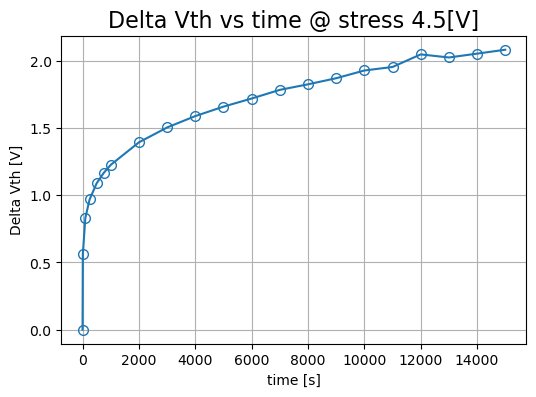

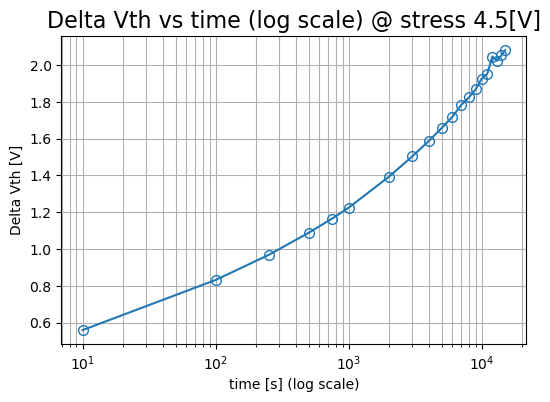

In [33]:
# time별 Delta Vth 계산 및 그래프
delta_vth_ref_time = min(vth_by_time_10.keys())
delta_vth_ref_value = vth_by_time_10[delta_vth_ref_time]

delta_vth_by_time = {}
for t in sorted(vth_by_time_10.keys()):
    vth_val = vth_by_time_10[t]
    if np.isnan(vth_val) or np.isnan(delta_vth_ref_value):
        delta_vth_by_time[t] = np.nan
    else:
        delta_vth_by_time[t] = vth_val - delta_vth_ref_value

delta_vth_df = pd.DataFrame({
    'time_s': sorted(delta_vth_by_time.keys()),
    'delta_vth': [delta_vth_by_time[t] for t in sorted(delta_vth_by_time.keys())]
})

print(f"Delta Vth reference: time={delta_vth_ref_time}[s], Vth={delta_vth_ref_value:.2f} V")
for _, row in delta_vth_df.iterrows():
    print(f"time={int(row['time_s'])}[s]: Delta Vth={row['delta_vth']:.2f} V")

plt.figure(figsize=(6, 4))
plt.plot(
    delta_vth_df['time_s'],
    delta_vth_df['delta_vth'],
    marker='o',
    markerfacecolor='none',
    markersize=7,
    linewidth=1.5
)
plt.xlabel('time [s]')
plt.ylabel('Delta Vth [V]')
plt.title('Delta Vth vs time @ stress 4.5[V]', fontsize=16)
plt.grid(True)
plt.show()

# time=0 은 log scale 에서 표시할 수 없어서 제외
delta_vth_df_log = delta_vth_df[delta_vth_df['time_s'] > 0].copy()

plt.figure(figsize=(6, 4))
plt.plot(
    delta_vth_df_log['time_s'],
    delta_vth_df_log['delta_vth'],
    marker='o',
    markerfacecolor='none',
    markersize=7,
    linewidth=1.5
)
plt.xscale('log')
plt.xlabel('time [s] (log scale)')
plt.ylabel('Delta Vth [V]')
plt.title('Delta Vth vs time (log scale) @ stress 4.5[V]', fontsize=16)
plt.grid(True, which='both')
plt.show()

Stretched exponential fit results
v_pre = 9.7156 V
tau   = 6956733.04 s
beta  = 0.2583
v_inf = 9.9999 V
R^2   = 0.9987


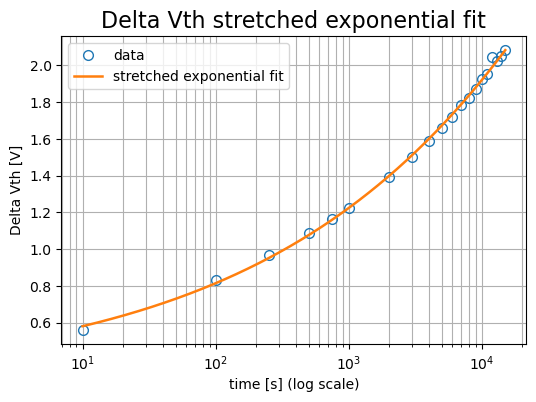

In [34]:
from scipy.optimize import curve_fit

def stretched_exponential(t, v_pre, tau, beta, v_inf):
    return -v_pre * np.exp(-((t / tau) ** beta)) + v_inf

fit_df = delta_vth_df[(delta_vth_df['time_s'] > 0) & delta_vth_df['delta_vth'].notna()].copy()

x_fit = fit_df['time_s'].to_numpy(dtype=float)
y_fit = fit_df['delta_vth'].to_numpy(dtype=float)

p0 = [max(y_fit.max() - y_fit.min(), 1e-3), np.median(x_fit), 0.5, y_fit.max()]
bounds = ([0, 1e-9, 0.05, 0], [10, 1e8, 1.5, 10])

popt, pcov = curve_fit(
    stretched_exponential,
    x_fit,
    y_fit,
    p0=p0,
    bounds=bounds,
    maxfev=20000
)

v_pre_fit, tau_fit, beta_fit, v_inf_fit = popt
y_pred = stretched_exponential(x_fit, *popt)
r2 = 1 - np.sum((y_fit - y_pred) ** 2) / np.sum((y_fit - y_fit.mean()) ** 2)

print('Stretched exponential fit results')
print(f'v_pre = {v_pre_fit:.4f} V')
print(f'tau   = {tau_fit:.2f} s')
print(f'beta  = {beta_fit:.4f}')
print(f'v_inf = {v_inf_fit:.4f} V')
print(f'R^2   = {r2:.4f}')

t_dense = np.logspace(np.log10(x_fit.min()), np.log10(x_fit.max()), 400)
y_dense = stretched_exponential(t_dense, *popt)

plt.figure(figsize=(6, 4))
plt.plot(x_fit, y_fit, 'o', markerfacecolor='none', markersize=7, label='data')
plt.plot(t_dense, y_dense, '-', linewidth=1.8, label='stretched exponential fit')
plt.xscale('log')
plt.xlabel('time [s] (log scale)')
plt.ylabel('Delta Vth [V]')
plt.title('Delta Vth stretched exponential fit', fontsize=16)
plt.grid(True, which='both')
plt.legend()
plt.show()


channel area = 8.0000e-06 cm^2
Cox_total = 4.2500e-12 pF
Cox_areal = 5.3125e-19 F/cm^2


,time_s,Vth_V,Delta_Vth_V,SS_mV_dec,peak_gm_S,Vg_at_peak_gm_V,Ion_A,Ioff_A,Ion_Ioff_ratio,Id_at_Vov_1.0V_A,Idsat_at_Vg_2.0V_A,Vd_linear_V,mu_FE_peak_cm2_Vs,mu_FE_at_Vov_1.0V_cm2_Vs
0,0,0.126494,0.000000,133.967099,7.978000e-07,2.80,1.548340e-06,2.890000e-13,5.357578e+06,2.494584e-07,8.504450e-07,0.1,7.508706e+12,5.141701e+12
1,10,0.685851,0.559357,144.944544,9.918000e-07,2.90,1.229590e-06,1.020000e-13,1.205480e+07,2.404440e-07,4.419390e-07,0.1,9.334588e+12,5.247825e+12
2,100,0.958471,0.831977,152.441687,9.134400e-07,2.90,9.369420e-07,9.900000e-14,9.464061e+06,2.260036e-07,2.488020e-07,0.1,8.597082e+12,5.063908e+12
3,250,1.094589,0.968095,154.645944,8.123800e-07,2.85,7.768180e-07,1.670000e-13,4.651605e+06,2.183482e-07,1.717340e-07,0.1,7.645929e+12,4.889661e+12
4,500,1.214972,1.088478,157.869427,7.319800e-07,2.90,6.503460e-07,1.640000e-13,3.965524e+06,2.126626e-07,1.169920e-07,0.1,6.889224e+12,4.733719e+12
5,750,1.291987,1.165493,157.738416,7.953600e-07,2.90,6.243950e-07,4.600000e-14,1.357380e+07,2.148891e-07,8.960120e-08,0.1,7.485741e+12,4.899775e+12
6,1000,1.351837,1.225342,159.041461,7.788400e-07,2.90,5.781700e-07,2.270000e-13,2.547004e+06,2.143319e-07,7.047920e-08,0.1,7.330259e+12,4.899894e+12
7,2000,1.519409,1.392915,159.306819,7.043400e-07,2.90,4.495720e-07,1.790000e-13,2.511575e+06,2.131059e-07,3.098030e-08,0.1,6.629082e+12,4.874334e+12
8,3000,1.629921,1.503426,158.739406,6.493800e-07,2.90,3.727860e-07,1.130000e-13,3.298991e+06,2.131289e-07,1.520740e-08,0.1,6.111812e+12,4.855912e+12
9,4000,1.714568,1.588073,158.651468,2.891400e-07,2.65,2.102120e-07,5.300000e-14,3.966264e+06,1.595565e-07,7.549930e-09,0.1,2.721318e+12,2.643728e+12


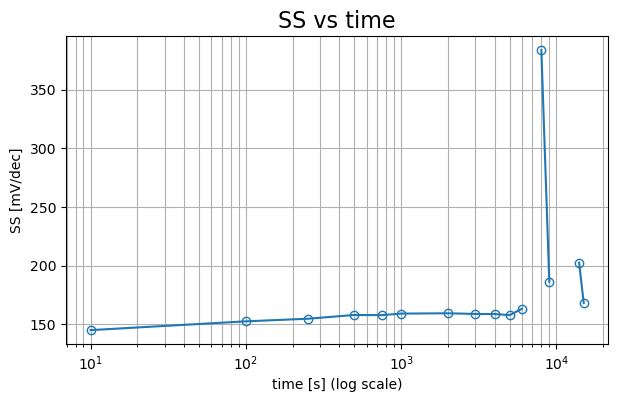

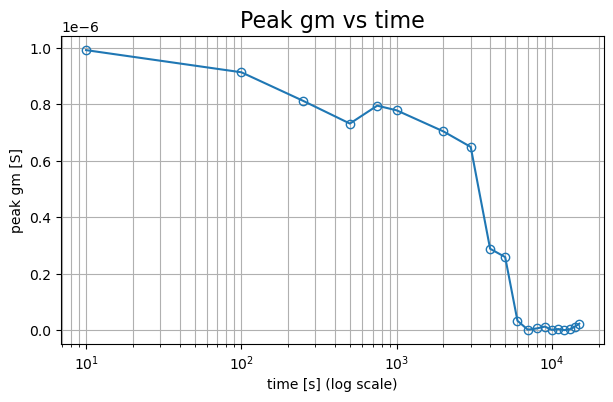

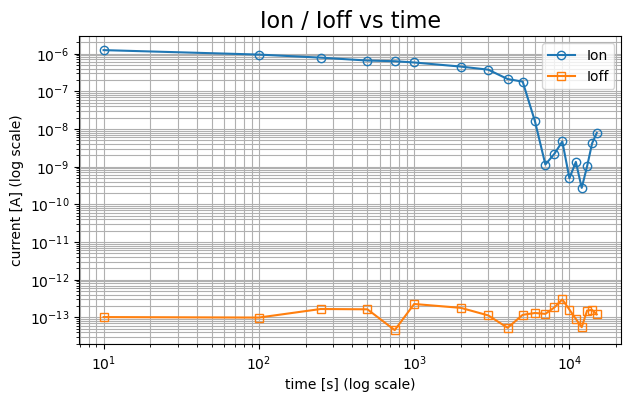

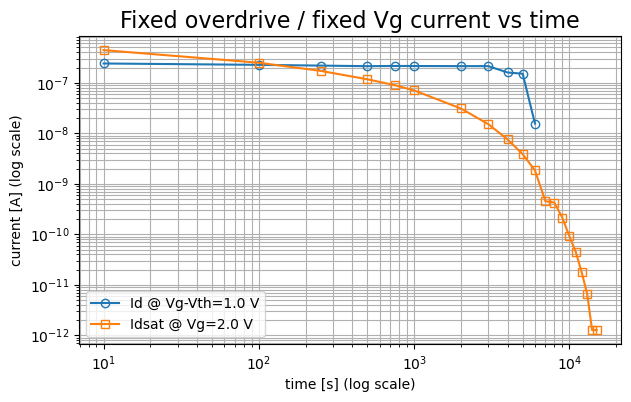

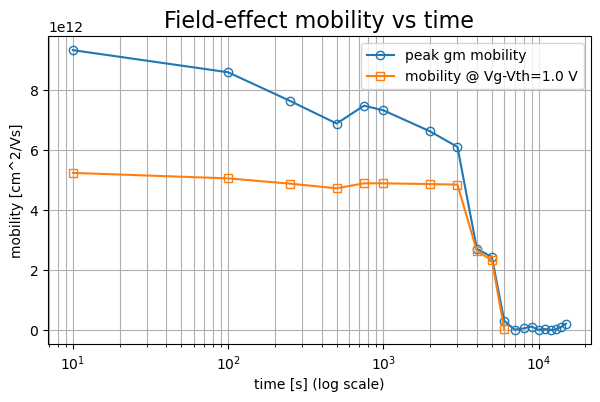

In [35]:
# 원인 분리를 위한 지표 정리
# 필요하면 아래 기준값만 바꿔서 다시 실행하면 됩니다.
overdrive_v = 1.0
fixed_vg_for_idsat = 2.0
cox_total_pf = 4.25e-12  # 예: "Cox_total[pF]": Cox_total_F * 1e12 에서 얻은 값

w_cm = W_um * 1e-4
l_cm = L_um * 1e-4
channel_area_cm2 = w_cm * l_cm
cox_total_f = cox_total_pf * 1e-12 if not np.isnan(cox_total_pf) else np.nan
cox_f_per_cm2 = cox_total_f / channel_area_cm2 if not np.isnan(cox_total_f) else np.nan

print(f'channel area = {channel_area_cm2:.4e} cm^2')
print(f'Cox_total = {cox_total_pf:.4e} pF')
print(f'Cox_areal = {cox_f_per_cm2:.4e} F/cm^2')

metric_rows = []

for t in sorted(plot_df['time_s'].unique()):
    g = plot_df[plot_df['time_s'] == t].sort_values('Vgate').copy()

    vg = g['Vgate'].to_numpy(dtype=float)
    vd = g['Vdrain'].to_numpy(dtype=float)
    id_abs = g['Idrain'].to_numpy(dtype=float)
    log_id = np.log10(np.clip(id_abs, 1e-300, None))
    gm = np.gradient(id_abs, vg)
    vd_linear_v = float(np.nanmedian(vd))

    vth = vth_by_time_10.get(t, np.nan)
    delta_vth = delta_vth_by_time.get(t, np.nan)
    ss_mv_dec = ss_by_vd.get(t, np.nan)

    ion = id_abs[-1]
    ioff = id_abs[0]
    peak_gm = np.nanmax(gm)
    gm_at_peak_idx = int(np.nanargmax(gm))
    vg_at_peak_gm = vg[gm_at_peak_idx]

    if np.isnan(vth):
        id_at_overdrive = np.nan
    else:
        target_vg = vth + overdrive_v
        if target_vg < vg.min() or target_vg > vg.max():
            id_at_overdrive = np.nan
        else:
            id_at_overdrive = np.interp(target_vg, vg, id_abs)

    if fixed_vg_for_idsat < vg.min() or fixed_vg_for_idsat > vg.max():
        idsat_fixed_vg = np.nan
    else:
        idsat_fixed_vg = np.interp(fixed_vg_for_idsat, vg, id_abs)

    if np.isnan(vth):
        gm_at_overdrive = np.nan
    else:
        target_vg = vth + overdrive_v
        if target_vg < vg.min() or target_vg > vg.max():
            gm_at_overdrive = np.nan
        else:
            gm_at_overdrive = np.interp(target_vg, vg, gm)

    if np.isnan(cox_f_per_cm2) or cox_f_per_cm2 <= 0 or np.isnan(vd_linear_v) or vd_linear_v == 0:
        mu_fe_peak_cm2_vs = np.nan
        mu_fe_vov_cm2_vs = np.nan
    else:
        mu_scale = l_cm / (w_cm * cox_f_per_cm2 * vd_linear_v)
        mu_fe_peak_cm2_vs = peak_gm * mu_scale
        mu_fe_vov_cm2_vs = gm_at_overdrive * mu_scale if not np.isnan(gm_at_overdrive) else np.nan

    metric_rows.append({
        'time_s': int(t),
        'Vth_V': vth,
        'Delta_Vth_V': delta_vth,
        'SS_mV_dec': ss_mv_dec,
        'peak_gm_S': peak_gm,
        'Vg_at_peak_gm_V': vg_at_peak_gm,
        'Ion_A': ion,
        'Ioff_A': ioff,
        'Ion_Ioff_ratio': ion / ioff if ioff > 0 else np.nan,
        f'Id_at_Vov_{overdrive_v:.1f}V_A': id_at_overdrive,
        f'Idsat_at_Vg_{fixed_vg_for_idsat:.1f}V_A': idsat_fixed_vg,
        'Vd_linear_V': vd_linear_v,
        'mu_FE_peak_cm2_Vs': mu_fe_peak_cm2_vs,
        f'mu_FE_at_Vov_{overdrive_v:.1f}V_cm2_Vs': mu_fe_vov_cm2_vs,
    })

metrics_df = pd.DataFrame(metric_rows)
display(metrics_df)

metrics_log_df = metrics_df[metrics_df['time_s'] > 0].copy()

plt.figure(figsize=(7, 4))
plt.plot(metrics_log_df['time_s'], metrics_log_df['SS_mV_dec'], marker='o', markerfacecolor='none')
plt.xscale('log')
plt.xlabel('time [s] (log scale)')
plt.ylabel('SS [mV/dec]')
plt.title('SS vs time', fontsize=16)
plt.grid(True, which='both')
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(metrics_log_df['time_s'], metrics_log_df['peak_gm_S'], marker='o', markerfacecolor='none')
plt.xscale('log')
plt.xlabel('time [s] (log scale)')
plt.ylabel('peak gm [S]')
plt.title('Peak gm vs time', fontsize=16)
plt.grid(True, which='both')
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(metrics_log_df['time_s'], metrics_log_df['Ion_A'], marker='o', markerfacecolor='none', label='Ion')
plt.plot(metrics_log_df['time_s'], metrics_log_df['Ioff_A'], marker='s', markerfacecolor='none', label='Ioff')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('time [s] (log scale)')
plt.ylabel('current [A] (log scale)')
plt.title('Ion / Ioff vs time', fontsize=16)
plt.grid(True, which='both')
plt.legend()
plt.show()

overdrive_col = f'Id_at_Vov_{overdrive_v:.1f}V_A'
idsat_col = f'Idsat_at_Vg_{fixed_vg_for_idsat:.1f}V_A'

plt.figure(figsize=(7, 4))
plt.plot(metrics_log_df['time_s'], metrics_log_df[overdrive_col], marker='o', markerfacecolor='none', label=f'Id @ Vg-Vth={overdrive_v:.1f} V')
plt.plot(metrics_log_df['time_s'], metrics_log_df[idsat_col], marker='s', markerfacecolor='none', label=f'Idsat @ Vg={fixed_vg_for_idsat:.1f} V')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('time [s] (log scale)')
plt.ylabel('current [A] (log scale)')
plt.title('Fixed overdrive / fixed Vg current vs time', fontsize=16)
plt.grid(True, which='both')
plt.legend()
plt.show()

if not np.isnan(cox_f_per_cm2) and cox_f_per_cm2 > 0:
    mu_peak_col = 'mu_FE_peak_cm2_Vs'
    mu_vov_col = f'mu_FE_at_Vov_{overdrive_v:.1f}V_cm2_Vs'

    plt.figure(figsize=(7, 4))
    plt.plot(metrics_log_df['time_s'], metrics_log_df[mu_peak_col], marker='o', markerfacecolor='none', label='peak gm mobility')
    plt.plot(metrics_log_df['time_s'], metrics_log_df[mu_vov_col], marker='s', markerfacecolor='none', label=f'mobility @ Vg-Vth={overdrive_v:.1f} V')
    plt.xscale('log')
    plt.xlabel('time [s] (log scale)')
    plt.ylabel('mobility [cm^2/Vs]')
    plt.title('Field-effect mobility vs time', fontsize=16)
    plt.grid(True, which='both')
    plt.legend()
    plt.show()
else:
    print('mobility is not calculated because cox_total_pf is not set.')
